# TODO: 
 ### should be pipleine of non batch correction and then combine.
 ### cnv_leiden

https://www.nature.com/articles/s41422-020-0374-x

In [3]:
# Always reload packages before executing user code
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Basic imports
import scanpy as sc

import sys, os

# Add parent directory to Python path
sys.path.append(os.path.abspath(".."))  

# Import pipeline functions

from scrna_pipeline import h5ad_builders,  annotation

### convert to anndata

In [5]:
# Path to raw AnnData file (adjust as needed)
path = '/Users/alahi.irfan/Desktop/Local_workspace/Data/Chen_CellRes_2020/GSE150430_npc_scRNA_hg19_processed_data.txt'


In [6]:
import pandas as pd

df = pd.read_csv(path, sep='\t')

display(df.head())

/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_2100/1446887945.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,

,N01_CAGAATCAGTAATCCC-1,N01_TGCGGGTAGTACGTAA-1,P01_CGGACTGGTCCTCCAT-1,P01_CTTCTCTGTGCACTTA-1,P01_AACTCCCAGTAGGTGC-2,P01_CGGACTGGTCCTCCAT-2,P03_CATGGCGAGCTCCTCT-1,P03_CGGTTAAAGACGACGT-1,P03_GAACCTATCAGCCTAA-1,P03_TAGTGGTTCGCCAAAT-1,...,P15_TTAGGACGTTCATGGT-1,P15_TTAGGCATCGTTTAGG-1,P15_TTAGTTCTCCCTTGCA-1,P15_TTATGCTGTGTTGAGG-1,P15_TTCGAAGAGTTTAGGA-1,P15_TTCGAAGCATCTACGA-1,P15_TTCTCCTGTCTAAACC-1,P15_TTCTCCTTCATTGCCC-1,P15_TTGACTTTCTCTGTCG-1,P15_TTTACTGTCCCTCTTT-1
Cell_type,CAFs,CAFs,CAFs,CAFs,CAFs,CAFs,CAFs,CAFs,CAFs,CAFs,...,DC2 (CD1C+),DC2 (CD1C+),DC2 (CD1C+),DC2 (CD1C+),Macrophage,Macrophage,Macrophage,Macrophage,Monocyte,DC2 (CD1C+)
RP11-34P13.7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RP11-34P13.8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AL627309.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AP006222.2,0,0,0,0.459,0.43,0,0,0,0,0.733,...,0,0,0,0,0,0,0,0,0,0


In [7]:
import numpy as np
import anndata as ad
from scipy import sparse

if "Cell_type" not in df.index:
    raise ValueError("Expected a row named 'Cell_type' in the first column (gene names).")

cell_type = df.loc["Cell_type"].astype(str)

# 3) Drop that row from expression matrix
expr = df.drop(index="Cell_type")

# (optional but recommended) ensure unique gene names
expr.index = expr.index.astype(str)
expr = expr[~expr.index.duplicated(keep="first")]

# 4) Build obs (cell metadata)
cell_ids = expr.columns.astype(str)
samples = pd.Index(cell_ids).str.split("_", n=1).str[0]   # sample = before first "_"

obs = pd.DataFrame(
    {
        "cell_id": cell_ids,
        "cell_type": cell_type.loc[cell_ids].values,  # align to columns
        "sample": samples,
    },
    index=cell_ids,
)

# 5) Build var (gene metadata)
var = pd.DataFrame(index=expr.index)
var.index.name = "gene"

# 6) Create AnnData (cells x genes)
X = expr.to_numpy(dtype=np.float32).T  # cells x genes

# optional: sparse (usually better for scRNA)
X = sparse.csr_matrix(X)

adata = ad.AnnData(X=X, obs=obs, var=var)



print(adata.n_obs, adata.n_vars)

48584 24720


In [8]:
adata.layers['log1p'] = adata.X.copy()

In [9]:
print(adata.var_names[:5])
print(adata.obs_names[:5])


Index(['RP11-34P13.7', 'RP11-34P13.8', 'AL627309.1', 'AP006222.2',
       'RP4-669L17.10'],
      dtype='object', name='gene')
Index(['N01_CAGAATCAGTAATCCC-1', 'N01_TGCGGGTAGTACGTAA-1',
       'P01_CGGACTGGTCCTCCAT-1', 'P01_CTTCTCTGTGCACTTA-1',
       'P01_AACTCCCAGTAGGTGC-2'],
      dtype='object')


In [10]:
adata.obs["sample"].value_counts()

sample
P15    7552
P03    6135
P02    6092
P08    5313
P11    2589
N01    2583
P13    2524
P14    2497
P06    2222
P01    2217
P10    2019
P07    1931
P12    1914
P05    1842
P09     834
P04     320
Name: count, dtype: int64

In [11]:
# from scrna_pipeline import pipeline

# marker_dict = {
#     "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
#     "T_cell": ["CD3D", "CD3E", "CD2", "CD8A", "CD4"],
#     "B_cell": ["MS4A1", "CD79A", "CD79B"],
#     "Myeloid": ["LYZ", "CD68", "CD14", "TYROBP", "LST1", "CSF1R", "FCGR3A"],
#     "Endothelial": ["PECAM1", "VWF", "KDR"],
#     "Fibroblast": ["COL1A1", "COL1A2", "DCN"],
#     "Mast": ["TPSAB1", "TPSB2", "CPA3"],
# }

# adata = pipeline.standard_cnv_pipeline(adata=adata, marker_dict=marker_dict,broad_celltype_key='test_broad_celltype')


In [12]:
# import numpy as np
# from scipy.sparse import issparse
# import infercnvpy as infercnv

# def cnv_view_for_plot(adata, sample, *, batch_key="sample", store_key="infercnv_per_batch"):
#     sub = adata[adata.obs[batch_key].astype(str) == str(sample)].copy()
#     store = adata.uns[store_key][str(sample)]

#     X = store["obsm"]["X_cnv"]

#     # unwrap the 0-d ndarray wrapper
#     if isinstance(X, np.ndarray) and X.ndim == 0:
#         X = X.item()

#     # make it a proper 2D array/matrix
#     if issparse(X):
#         X = X.toarray()
#     else:
#         X = np.asarray(X)
#         if X.ndim != 2:
#             raise ValueError(f"X_cnv is not 2D after unwrap. ndim={X.ndim}, shape={X.shape}")

#     if X.shape[0] != sub.n_obs:
#         raise ValueError(f"X_cnv rows ({X.shape[0]}) != sub.n_obs ({sub.n_obs})")

#     sub.obsm["X_cnv"] = X
#     sub.uns["cnv"] = store["uns"]["cnv"]
#     return sub


# for s in ["P03", "N01"]:
#     sub = cnv_view_for_plot(adata, s)
#     infercnv.pl.chromosome_heatmap(sub, groupby="test_broad_celltype", dendrogram=True)


In [13]:
keep_samples = [ "P03","N01"]

adata = adata[adata.obs["sample"].isin(keep_samples)]

In [14]:
adata.obs["cell_type"].value_counts()

cell_type
B cell-1                    1817
CD4+ Tconv-2                 751
B cell-2                     730
Plasma cell                  467
FCRL4+ B cell                435
CD4+ Tconv-1                 358
CD4+ Tregs-2                 326
DC2 (CD1C+)                  323
CD4+ Tregs-1                 312
Malignant                    300
CD8+ T-1                     297
CD4+ Tconv-3                 289
CD8+ T-3                     281
pDC                          273
GC B cell                    261
CD8+ T-2                     261
B cell-3                     258
Non-malignant epithelial     207
Macrophage                   199
B cell-4                     161
CD8+ Tdys                    154
NK                           114
DC3 (CCR7+)                   62
Monocyte                      41
DC1 (CLEC9A+)                 28
CAFs                          13
Name: count, dtype: int64

In [15]:
import numpy as np

ct = adata.obs["cell_type"].astype(str)

def to_broad_celltype(x: str) -> str:
    x = x.strip()

    # CAF
    if x == "CAFs":
        return "CAFs"

    # Epithelial (incl malignant/non-malignant epi)
    if "epithelial" in x.lower() or x.lower().startswith("malignant"):
        return "Epithelial"

    # B lineage
    if ("b cell" in x.lower()) or ("plasma" in x.lower()) or ("gc b" in x.lower()) or ("fcrl4+ b" in x.lower()):
        return "B cell"

    # T lineage
    if x.startswith("CD4") or x.startswith("CD8") or ("tconv" in x.lower()) or ("tregs" in x.lower()) or ("tdys" in x.lower()):
        return "T cell"

    # Myeloid / APCs (monocyte, macrophage, DCs, pDC)
    if ("mono" in x.lower()) or ("macro" in x.lower()) or x.lower().startswith("dc") or ("pdc" in x.lower()):
        return "Myeloid"

    # NK is not in your requested set; choose where you want it to go:
    if x.lower() == "nk":
        return "T cell"   # or "Myeloid" or "Other" (your call)

    return "Other"

adata.obs["broad_cell_type"] = ct.map(to_broad_celltype).astype("category")

adata.obs["broad_cell_type"].value_counts()
pd.crosstab(adata.obs["cell_type"], adata.obs["broad_cell_type"])



/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_2100/538320710.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["broad_cell_type"] = ct.map(to_broad_celltype).astype("category")


broad_cell_type,B cell,CAFs,Epithelial,Myeloid,T cell
cell_type,,,,,
B cell-1,1817,0,0,0,0
B cell-2,730,0,0,0,0
B cell-3,258,0,0,0,0
B cell-4,161,0,0,0,0
CAFs,0,13,0,0,0
CD4+ Tconv-1,0,0,0,0,358
CD4+ Tconv-2,0,0,0,0,751
CD4+ Tconv-3,0,0,0,0,289
CD4+ Tregs-1,0,0,0,0,312


### HVG

In [16]:
n_top_genes = 2000
hvg_flavor = 'seurat'
batch_key = 'sample'
scaled_hvg_layer_key= "scaled_hvg",

In [17]:
from anndata import AnnData
sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_top_genes,
        flavor=hvg_flavor,
        batch_key=batch_key,
    )

if "highly_variable" not in adata.var:
        raise RuntimeError("Expected `adata.var['highly_variable']` before scaling.")

hvgs = adata.var["highly_variable"].to_numpy()
n_hvg = int(hvgs.sum())
if n_hvg == 0:
    raise RuntimeError("No HVGs were selected (adata.var['highly_variable'].sum() == 0).")

X0 = adata.X  # log1p all genes (keep this as the canonical .X)

# Scale HVGs in a version-stable way:
# - make a temporary AnnData containing only HVGs
# - run sc.pp.scale on that (no `use_highly_variable` arg needed)
# - write scaled HVGs into a full-size matrix layer for PCA use
X_hvg = adata.X[:, hvgs].copy()

tmp = AnnData(X=X_hvg)
sc.pp.scale(tmp, max_value=10, zero_center=True)

# Build a full (cells x genes) layer, but only HVG columns are scaled.
# Non-HVG columns are left as the original log1p values; they won't be used
# for PCA because we pass `use_highly_variable=True`.
try:
    # If X0 is sparse, assignment into sparse is painful.
    # Create a dense layer for scaled_hvg (HVG count is small; dense is ok).
    scaled_full = np.asarray(X0.todense() if hasattr(X0, "todense") else X0).copy()
except Exception:
    scaled_full = np.asarray(X0).copy()

scaled_full[:, hvgs] = np.asarray(tmp.X)

adata.layers[scaled_hvg_layer_key] = scaled_full

# Restore `.X` (unchanged)
adata.X = X0

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


### PCA

In [18]:
if scaled_hvg_layer_key:
    sc.tl.pca(
        adata,
        n_comps=50,
        svd_solver="arpack",
        random_state=0,
        use_highly_variable=True,
        layer=scaled_hvg_layer_key,
    )

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


### Batch Correction

In [19]:
from scrna_pipeline import batch_correction
rep_key = batch_correction.apply_batch_correction(
        adata,
        method="none", #"harmony",
        batch_key=batch_key,
        rep_in="X_pca"
    )

### UMAP

In [20]:
from scrna_pipeline import clustering

n_neighbors = 15
clustering_method = 'leiden'
cluster_resolution = 0.6

adata = clustering.cluster_and_embed(
    adata,
    rep_key=rep_key,
    n_neighbors=n_neighbors,
    clustering_method=clustering_method,
    resolution=cluster_resolution
)

/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/clustering.py:108: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


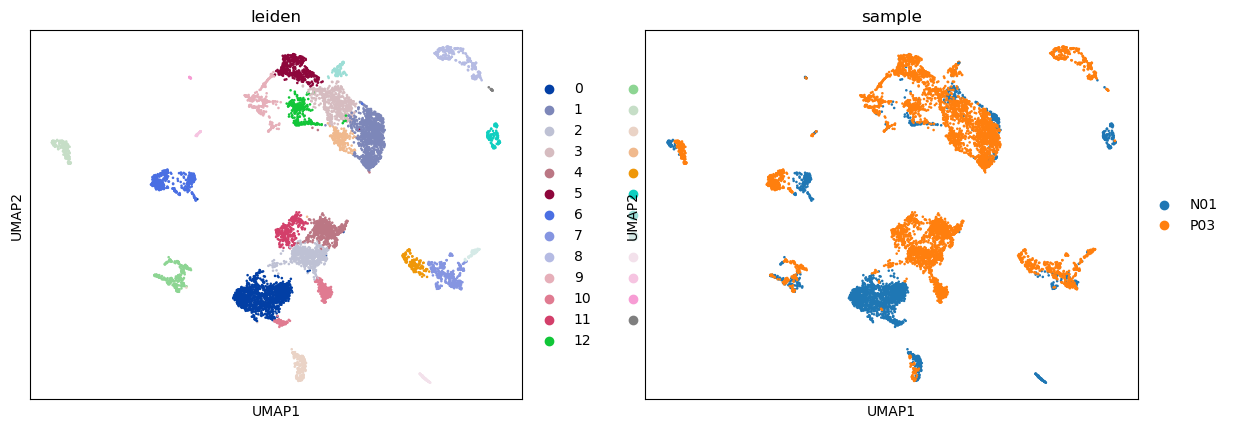

In [21]:
sc.pl.umap(adata, color=['leiden','sample']) #, legend_loc='on data')

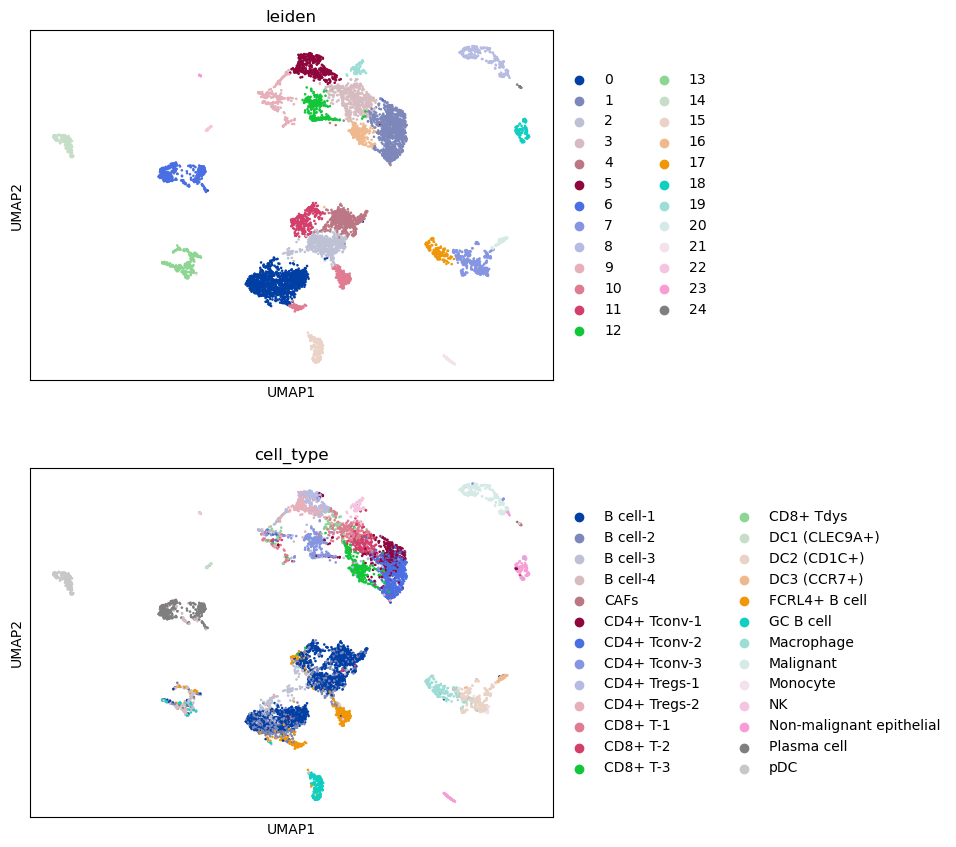

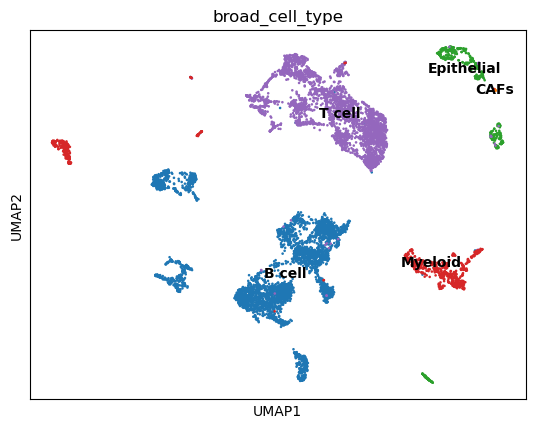

In [22]:
sc.pl.umap(adata, color=['leiden','cell_type'], ncols=1) 
sc.pl.umap(adata, color=['broad_cell_type'], legend_loc='on data') 

/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


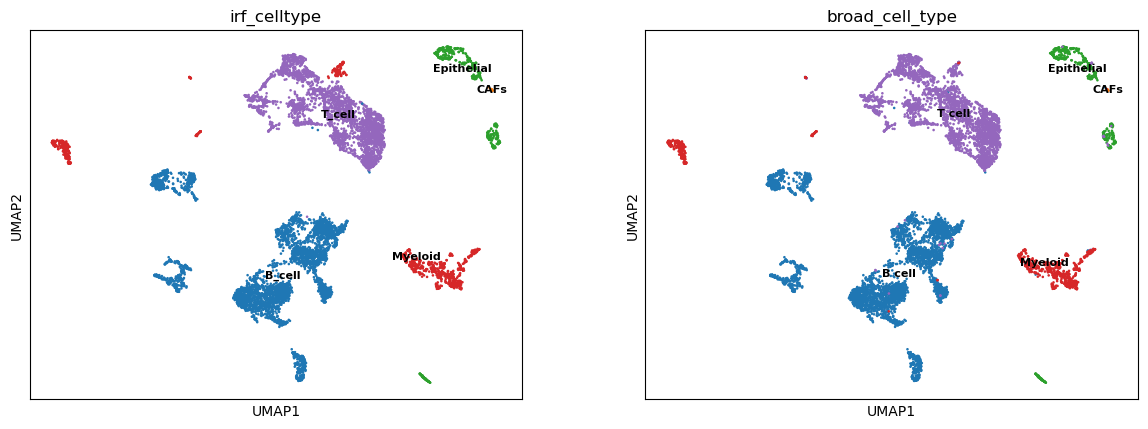

In [23]:
from scrna_pipeline import annotation

marker_dict = {
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T_cell": ["CD3D", "CD3E", "CD2", "CD8A", "CD4"],
    "B_cell": ["MS4A1", "CD79A", "CD79B"],
    "Myeloid": ["LYZ", "CD68", "CD14", "TYROBP", "LST1", "CSF1R", "FCGR3A"],
    "CAFs" : ["CLO1A1","COL3A1","DCN"]
}

# Compute cluster-level marker scores + suggested labels
cluster_scores, suggested_labels = annotation.score_markers_and_suggest_labels(
    adata,
    marker_dict,
    cluster_key='leiden',
)

# Store suggested cell type labels
adata.obs["irf_celltype"] = adata.obs['leiden'].map(suggested_labels)

sc.pl.umap(
    adata,
    color=["irf_celltype", "broad_cell_type"],
    legend_loc="on data",
    legend_fontsize=8,
)


### infercnv

In [24]:
from scrna_pipeline.tumor_cell_classification import cnv

cnv.run_infercnv(adata, reference_key="irf_celltype", reference_cat=["T_cell","B_cell"], layer='log1p')

[GTF] Using cached GTF: /Users/alahi.irfan/.cache/genome/gtf/gencode.v44.annotation.gtf
[add_gene_positions] Reading GTF: /Users/alahi.irfan/.cache/genome/gtf/gencode.v44.annotation.gtf
[add_gene_positions] Positions added. Missing genes: 7703/24720


  0%|          | 0/2 [00:00<?, ?it/s]/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
100%|██████████| 2/2 [00:17<00:00,  8.55s/it]


AnnData object with n_obs × n_vars = 8718 × 24720
    obs: 'cell_id', 'cell_type', 'sample', 'broad_cell_type', 'leiden', 'Epithelial_score', 'T_cell_score', 'B_cell_score', 'Myeloid_score', 'CAFs_score', 'irf_celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'chromosome', 'start', 'end'
    uns: 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'sample_colors', 'cell_type_colors', 'broad_cell_type_colors', 'irf_celltype_colors', 'cnv'
    obsm: 'X_pca', 'X_umap', 'X_cnv'
    varm: 'PCs'
    layers: 'log1p', ('scaled_hvg',)
    obsp: 'distances', 'connectivities'

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1431 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: B_cell, CAFs, Epithelial, etc.
var_group_labels: chr1, chr2, chr3, etc.


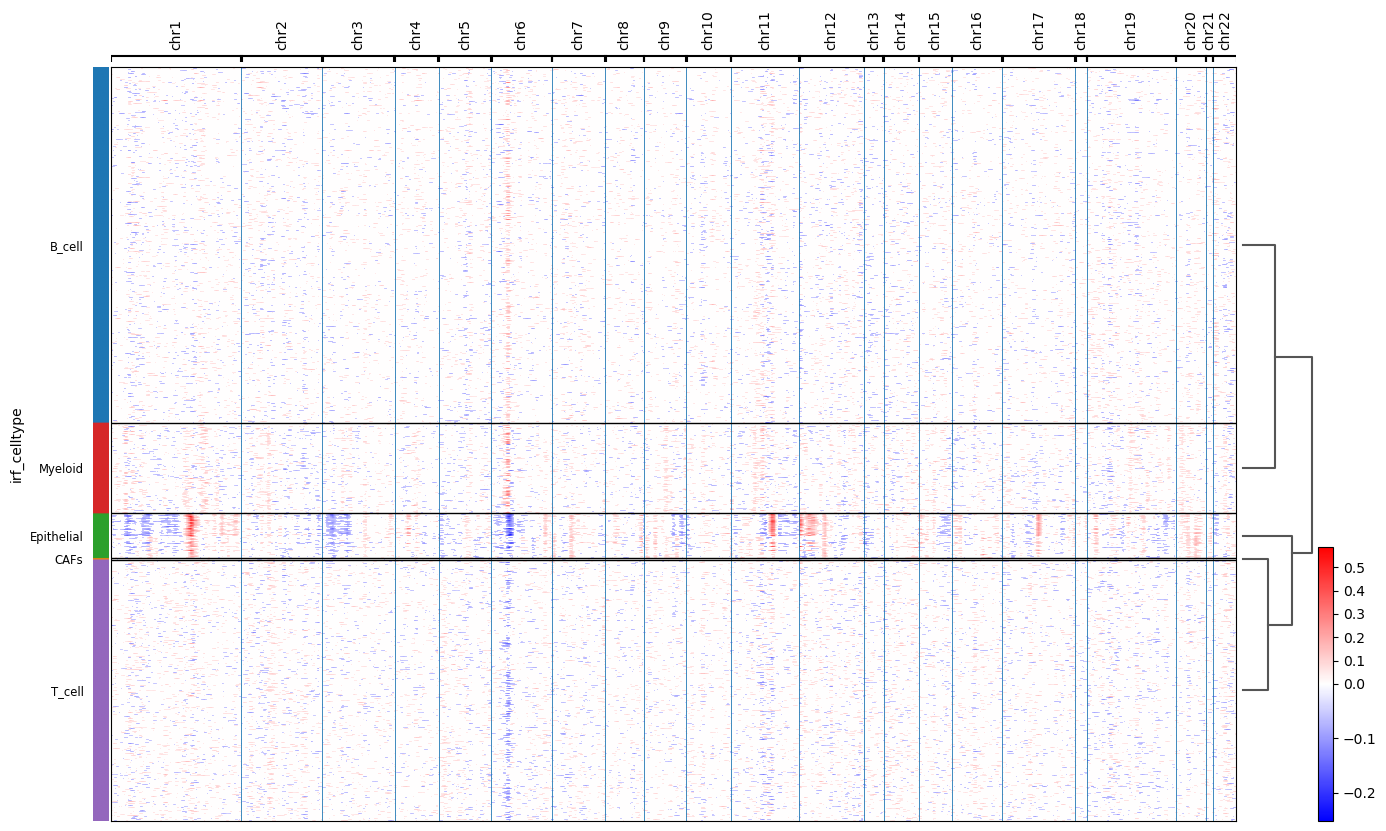

In [25]:
import infercnvpy as infercnv
infercnv.pl.chromosome_heatmap(adata, groupby="irf_celltype", dendrogram=True)

/opt/miniconda3/envs/scrna-pipeline/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1431 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


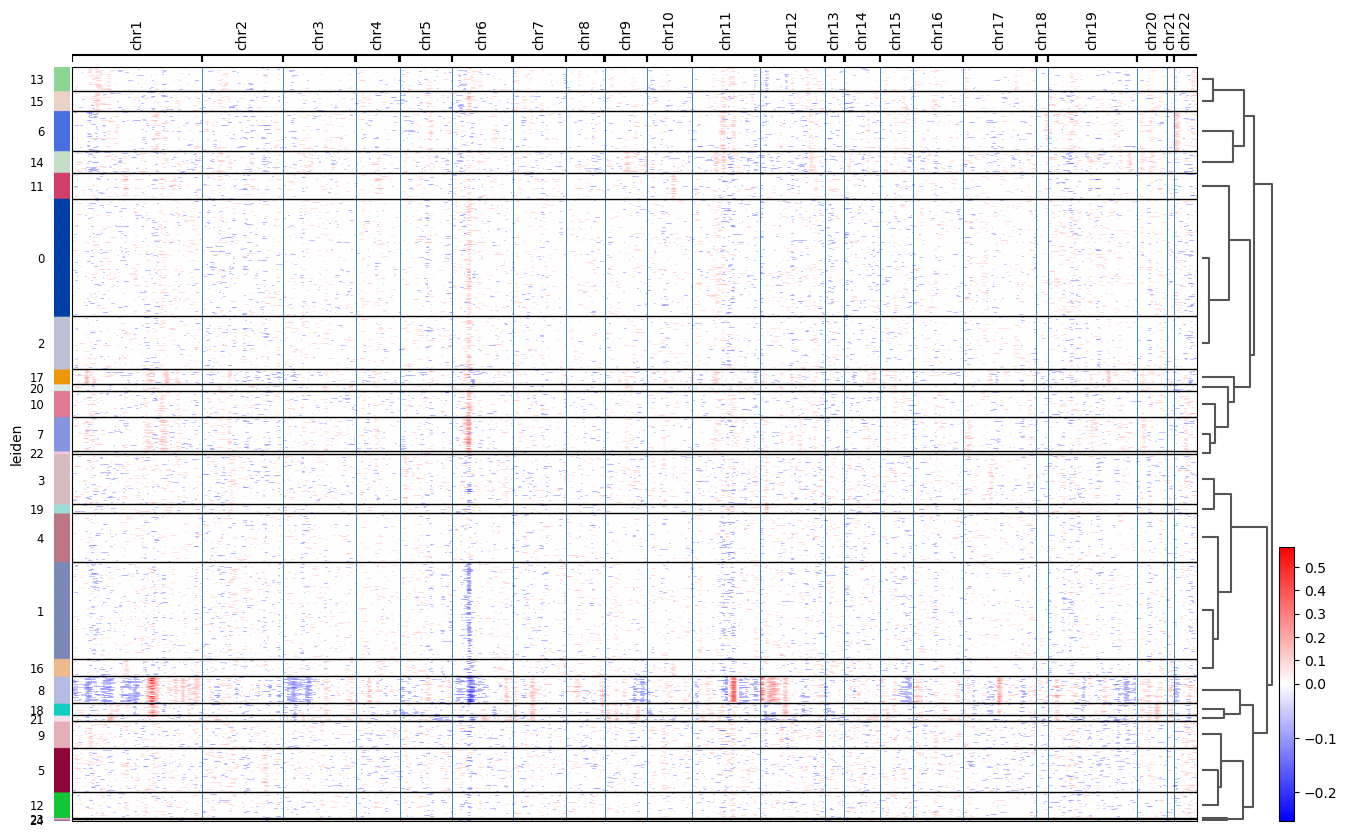

In [26]:
infercnv.pl.chromosome_heatmap(adata, groupby="leiden", dendrogram=True)

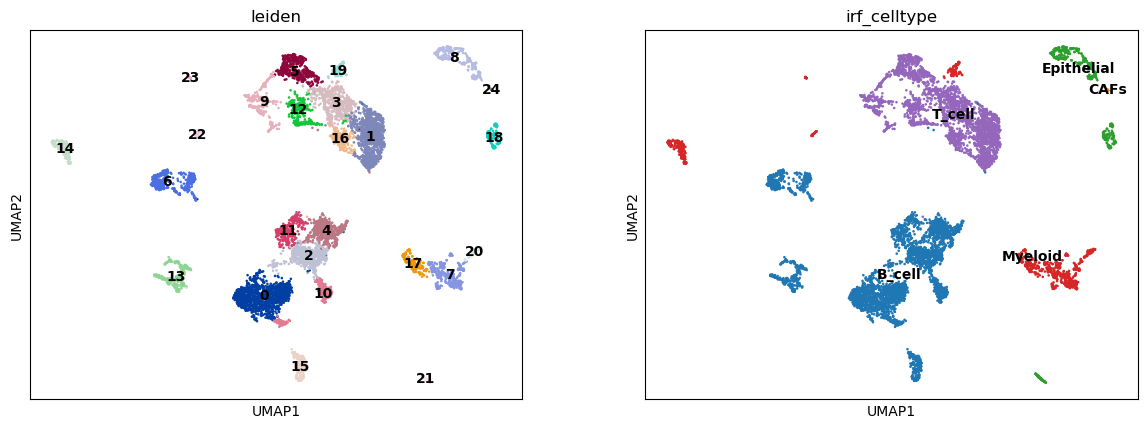

In [27]:
sc.pl.umap(adata, color=['leiden','irf_celltype'], legend_loc='on data') 